# Tramos lineales de la rampa

**Objetivo:** determinar qué parte de cada pata de la rampa puede usarse como tramo de velocidad aproximadamente constante y a qué velocidad se mueve la platina.

El análisis usa dos criterios independientes:

1. **Método A — error del controlador:** el tramo lineal es donde el error permanece cerca de su meseta. Es un comando directo del controlador
2. **Método de posición:** ajustar la ida por una recta y determinar la parte lineal con los residuos.

En ambos casos, la **velocidad final se obtiene ajustando una recta a la posición medida** en el tramo seleccionado.


## 0. Carga y funciones de análisis


In [1]:
# =============================================================================
#  CELDA 0
# =============================================================================
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def buscar_repo():
    for d in (Path.cwd(), *Path.cwd().parents):
        if (d / "datos/raw").is_dir():
            return d
    destino = Path.cwd() / "laboratorio-7"
    if not (destino / "datos/raw").is_dir():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/franaguirreram/laboratorio-7.git",
                        str(destino)], check=True)
    return destino

REPO = buscar_repo()

RAW, META = REPO / "datos/raw", REPO / "datos/metadata"
T_SERVO_US = 39.999984            # [MEDIDO] periodo del lazo de servo del E-517

plt.rcParams.update({"font.family": "serif", "font.size": 9, "figure.dpi": 120,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5})
C_CMD, C_MED, C_SUD = "0.55", "#1f77b4", "#ff7f0e"
C_ERR, C_RECTA = "#d62728", "#2ca02c"      # un color por método


def leer_meta(stem):
    lineas = (META / f"{stem}_metadata.txt").read_text().splitlines()
    return dict(l.split("=", 1) for l in lineas if "=" in l and not l.startswith("#"))


def cargar(stem):
    """Una corrida, reducida a la grilla de PUNTOS de la wave (un valor por pixel).

    El generador mantiene el setpoint quieto WTR ciclos de servo y recien ahi lo
    cambia: ese peldaño es el PIXEL del scan. Promediar las muestras de cada
    peldaño es lo que hace un detector integrando sobre el pixel, y
    deja todo el analisis sobre una grilla de n_total puntos.
    """
    m = leer_meta(stem)
    df = pd.read_csv(RAW / f"{stem}.csv")
    wtr, rtr, n_pedido = int(m["wtr"]), int(m["rtr"]), int(m["n_total"])
    mpp = max(wtr // rtr, 1)                      # muestras grabadas por punto

    x_cmd = df["target_um"].to_numpy()

    # arranque de la wave, leido del comando.
    recorrido = x_cmd.max() - x_cmd.min()
    a = int(np.argmax(np.abs(x_cmd - x_cmd[0]) > recorrido / 1000)) # punto inicial
    n = min(n_pedido, (len(x_cmd) - a) // mpp)    # si la wave es mas grande que el tiempo de lectura
    pixel = lambda y: y[a:a + n * mpp].reshape(n, mpp).mean(axis=1)

    r = {"stem": stem, "wtr": wtr, "rtr": rtr, "sud": int(m["speedupdown"]),
         "n_total": n_pedido, "n_pt": n, "amplitud_um": float(m["amplitud_um"]),
         "muestras_por_punto": mpp, "arranque": a,
         "dwell_ms": wtr * T_SERVO_US / 1e3,      # lo que dura un punto
         "dt_ms": rtr * T_SERVO_US / 1e3,         # lo que dura una muestra
         "t_ms": np.arange(len(x_cmd)) * rtr * T_SERVO_US / 1e3,
         "x_cmd": x_cmd, "x_med": df["current_um"].to_numpy(),
         "err_nm_crudo": df["error_um"].to_numpy() * 1e3}
    r["k"] = np.arange(n)                          # numero de punto (pixel)
    r["t_pt"] = (a + (np.arange(n) + 0.5) * mpp) * r["dt_ms"]
    r["cmd"], r["med"] = pixel(x_cmd), pixel(r["x_med"])
    r["err"] = pixel(r["err_nm_crudo"])            # error del CONTROLADOR, en nm

    # la ida son los primeros n_total/2 puntos y la vuelta el resto: lo dice el
    # generador, no hace falta buscar el pico (que con SUD > 0 es una meseta)
    h = min(n_pedido // 2, n)
    r["patas"] = {"ida": np.arange(0, h), "vuelta": np.arange(h, n)}

    # SUD = los puntos que el generador gasta acelerando y frenando en cada punta
    sud = r["sud"]
    r["es_sud"] = np.zeros(n, bool)
    for idx in r["patas"].values():
        if len(idx) and sud:
            r["es_sud"][idx[:sud]] = True
            r["es_sud"][idx[-sud:]] = True

    # dx (el tamano del pixel) se MIDE: con SUD > 0 el generador reparte los
    # puntos de forma no uniforme.
    # Tomo el maximo de los pasos entre puntos consecutivos
    paso = np.abs(np.diff(r["cmd"]))
    r["dx_nm"] = float(np.max(paso) * 1e3)
    return r


## 1. Selección de las corridas utilizables

Se conservan únicamente las corridas que:
- son de **modo rampa**;
- terminaron con `ok=True`;
- contienen las cuatro señales necesarias;
- tienen **RTR = 1**, para trabajar siempre con la misma resolución temporal.

`RTR = 1` implica una muestra cada período de servo, `T_SERVO_US ≈ 40 µs`.


In [2]:
# ---------------------------------------------------------------------------
# SELECCIÓN DE CORRIDAS
# ---------------------------------------------------------------------------
COLUMNAS = {"t_ms", "target_um", "current_um", "error_um"}


def cabecera_csv(ruta):
    """Lee sólo los nombres de columna, sin cargar los datos de la corrida."""
    with ruta.open(encoding="utf-8") as archivo:
        return set(archivo.readline().strip().split(","))


filas = []
for ruta_csv in sorted(RAW.glob("E517_rampa_*.csv")):
    try:
        metadata = leer_meta(ruta_csv.stem)
    except OSError:
        continue

    # Primero filtramos con metadata. Así no abrimos el CSV de una corrida que
    # ya sabemos que no pertenece a esta tabla.
    if (metadata.get("modo"), metadata.get("ok"), metadata.get("rtr")) != (
        "rampa", "True", "1"
    ):
        continue

    # Las cuatro columnas son las mínimas necesarias para este análisis.
    # Las corridas de diafonía tienen columnas distintas y quedan fuera.
    try:
        if not COLUMNAS <= cabecera_csv(ruta_csv):
            continue
    except OSError:
        continue

    filas.append({
        "stem": ruta_csv.stem,
        "amplitud_um": float(metadata["amplitud_um"]),
        "n_total": int(metadata["n_total"]),
        "wtr": int(metadata["wtr"]),
        "sud": int(metadata["speedupdown"]),
    })

RAMPAS = (
    pd.DataFrame(filas)
    .sort_values(["amplitud_um", "n_total", "wtr", "sud", "stem"])
    .reset_index(drop=True)
)

# En una rampa triangular hay n_total/2 puntos por pata y una excursión
# de 2*A. Por eso, si no hubiera SUD, el paso nominal sería:
#       dx_nominal = 2*A / (n_total/2) = 4*A/n_total.
RAMPAS["dx_nominal_nm"] = 4e3 * RAMPAS.amplitud_um / RAMPAS.n_total

# WTR indica cuántos ciclos de servo permanece cada punto:
#       dwell = WTR * T_SERVO.
RAMPAS["dwell_us"] = RAMPAS.wtr * T_SERVO_US

# Velocidad nominal asociada al paso nominal.
RAMPAS["v_nominal_um_s"] = (
    RAMPAS["dx_nominal_nm"] / 1e3
    / (RAMPAS["dwell_us"] * 1e-6)
)

print(
    f"{len(RAMPAS)} corridas utilizables · "
    f"WTR = {sorted(map(int, RAMPAS.wtr.unique()))} · "
    f"SUD = {sorted(map(int, RAMPAS.sud.unique()))}"
)


91 corridas utilizables · WTR = [5, 10, 20] · SUD = [0, 10, 20, 40, 80]


In [22]:
# ---------------------------------------------------------------------------
# RECUPERACIÓN Y COMPARACIÓN DE CORRIDAS UTILIZABLES
# ---------------------------------------------------------------------------

# Índice visible para seleccionar corridas desde RAMPAS.
display(
    RAMPAS.reset_index(names="indice")[
        ["indice", "stem", "amplitud_um", "n_total", "wtr", "sud",
         "v_nominal_um_s"]
    ].round({"v_nominal_um_s": 2})
)

# Caché para no volver a leer del disco una corrida ya cargada.
_CACHE_CORRIDAS = {}


def obtener_corrida(indice):
    """Devuelve la corrida utilizable correspondiente a su índice en RAMPAS."""
    indice = int(indice)

    if indice < 0 or indice >= len(RAMPAS):
        raise IndexError(f"El índice debe estar entre 0 y {len(RAMPAS) - 1}.")

    if indice not in _CACHE_CORRIDAS:
        stem = RAMPAS.iloc[indice]["stem"]
        _CACHE_CORRIDAS[indice] = cargar(stem)

    return _CACHE_CORRIDAS[indice]


,indice,stem,amplitud_um,n_total,wtr,sud,v_nominal_um_s
0,0,E517_rampa_tau_A0.05um_20260909_154848_r0,0.05,400,20,0,0.63
1,1,E517_rampa_tau_A0.05um_20260909_154853_r1,0.05,400,20,0,0.63
2,2,E517_rampa_tau_A0.1um_20260909_154858_r0,0.10,400,20,0,1.25
3,3,E517_rampa_tau_A0.1um_20260909_154903_r1,0.10,400,20,0,1.25
4,4,E517_rampa_tau_A0.1um_20260909_155116_r0,0.10,400,20,0,1.25
...,...,...,...,...,...,...,...
86,86,E517_rampa_tau_A30um_20260909_170304_r1,30.00,400,20,0,375.00
87,87,E517_rampa_tau_A30um_20260909_174146_r0,30.00,400,20,0,375.00
88,88,E517_rampa_tau_A30um_20260909_174151_r1,30.00,400,20,0,375.00
89,89,E517_rampa_tau_A30um_20260909_174305_r0,30.00,400,20,10,375.00


## 2. Corrida representativa: comandada, medida y SUD

Los puntos SUD (speedupdown) son los puntos que el generador utiliza en cada punta para acelerar y frenar. Se muestran aparte porque no representan el régimen aproximadamente uniforme de la pata.


WTR=10 · SUD=40 · amplitud=1.0 µm · puntos=400 · dx medido=12.7 nm


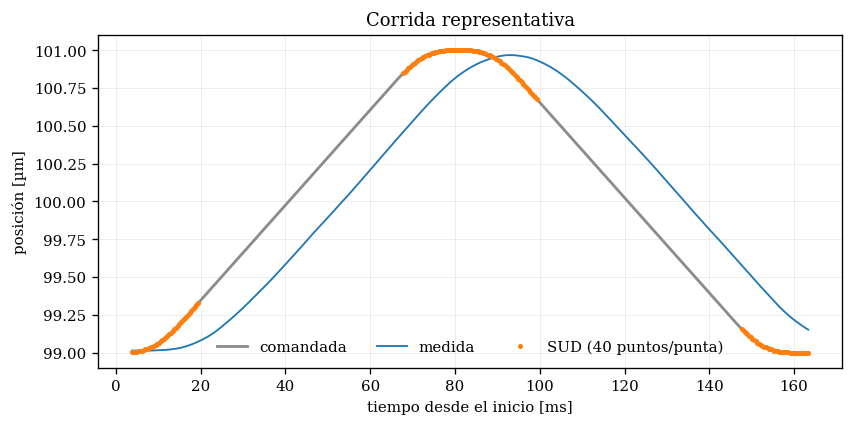

In [4]:
# ---------------------------------------------------------------------------
# CORRIDA REPRESENTATIVA
# ---------------------------------------------------------------------------
# Cambiar solamente este nombre permite analizar otra medición.
CORRIDA = "E517_rampa_scan_w10_sud40_20260907_172930_r0"

r = cargar(CORRIDA)

print(
    f"WTR={r['wtr']} · SUD={r['sud']} · "
    f"amplitud={r['amplitud_um']} µm · puntos={r['n_pt']} · "
    f"dx medido={r['dx_nm']:.1f} nm"
)

fig, ax = plt.subplots(figsize=(8, 3.6))

ax.plot(r["t_pt"], r["cmd"], color=C_CMD, lw=1.7, label="comandada")
ax.plot(r["t_pt"], r["med"], color=C_MED, lw=1.1, label="medida")

# Se resaltan únicamente los puntos SUD de la señal comandada.
# Son los puntos consumidos en las zonas de aceleración/frenado.
ax.plot(
    r["t_pt"][r["es_sud"]],
    r["cmd"][r["es_sud"]],
    ".",
    color=C_SUD,
    ms=4,
    label=f"SUD ({r['sud']} puntos/punta)",
)

ax.set_xlabel("tiempo desde el inicio [ms]")#("punto de la wave (pixel)")
ax.set_ylabel("posición [µm]")
ax.legend(frameon=False, ncol=3)
ax.set_title("Corrida representativa")
plt.show()


## 3. Tramo lineal: Método A y método de posición

Se usa la misma tolerancia, `TOL`, en ambos criterios:

$|s - s_\mathrm{meseta}| \leq TOL \,(\max s-\min s)$.

Con `TOL = 0.05`, se acepta una desviación de hasta **5 % del rango propio de la señal**.

Una vez determinado el tramo, la velocidad **no** se obtiene dividiendo simplemente dos puntos. Se ajusta

$x(t)=x_0+vt$,

de modo que la pendiente `v` es la velocidad y la covarianza del ajuste proporciona su incertidumbre.


In [5]:
# =============================================================================
#  FUNCIONES DE ANALISIS
# =============================================================================
# EL PROCEDIMIENTO, UNA SOLA VEZ Y EN PALABRAS
#
#   1. la ida y la vuelta se tratan por separado (son los primeros y los ultimos
#      n_total/2 puntos: lo dice el generador, no hace falta buscar el pico);
#   2. se elige una SEÑAL que se quede quieta mientras la platina va a velocidad
#      constante. Hay dos, y son independientes entre si:
#         metodo 1 -> el error que mide el controlador, que en una rampa vale
#                     e = -v*tau y por lo tanto es constante si v lo es;
#         metodo 2 -> el residuo de la posicion medida contra una recta, que es
#                     cero mientras la posicion sea una recta en el tiempo;
#   3. se define una BANDA de tolerancia alrededor del valor que esa señal toma
#      cuando esta quieta (su MESETA);
#   4. el TRAMO LINEAL es la racha contigua mas larga que cae dentro de la banda;
#   5. sobre ese tramo se ajusta x(t) = x0 + v*t: la pendiente es la velocidad y
#      la covarianza del ajuste da su incertidumbre.
#
# Cada metodo es UNA funcion que hace esos pasos, numerados adentro. Lo unico
# que comparten son las tres herramientas de aca abajo.


# ------------------------------------------------------------- herramientas --
def tramo_mas_largo(mascara):
    """La racha contigua mas larga de True. Devuelve posiciones dentro de la pata.

    Hace falta porque la señal puede entrar y salir de la banda varias veces (al
    arrancar, por ejemplo, o por ruido); lo que interesa es el pedazo seguido
    mas largo, no todos los puntos sueltos que cumplen la condicion.
    """
    posiciones = np.where(mascara)[0]
    if not len(posiciones):
        return posiciones
    cortes = np.where(np.diff(posiciones) > 1)[0] + 1
    return max(np.split(posiciones, cortes), key=len)


def ajustar(r, idx):
    """Velocidad de la platina en un tramo: pendiente de x_med contra t, con su error.

    Es el paso 5, y el unico numero que se le pide al final a cualquiera de los
    dos metodos. La velocidad NO sale de dividir dos puntos: sale del ajuste de
    todos los puntos del tramo, y de ahi tambien sale su incertidumbre.
    """
    if len(idx) < 3:
        return np.nan, np.nan
    p, cov = np.polyfit(r["t_pt"][idx] * 1e-3, r["med"][idx], 1, cov=True)
    return float(p[0]), float(np.sqrt(cov[0, 0]))


def meseta_y_rango(senal, pata):
    """El valor de la meseta de una señal dentro de una pata, y su rango max - min.

    Los dos robustos (percentiles 2 y 98, no el maximo y el minimo pelados, que
    son un solo punto y por lo tanto puro ruido). La meseta es el extremo del
    rango del lado donde la señal se estabiliza: como la señal pasa ahi la mayor
    parte de la pata, es el extremo mas cercano a la mediana.
    """
    lo, hi = np.percentile(senal[pata], [2, 98])
    centro = np.median(senal[pata])
    meseta = hi if abs(hi - centro) < abs(lo - centro) else lo
    return meseta, hi - lo


# ------------------------------------------- METODO 1: el error del controlador
def tramo_por_error(r, tol):
    """El tramo lineal es donde el error del controlador esta en su meseta.

    En una rampa el lazo se atrasa una cantidad fija, e = -v*tau: el error
    arranca en cero, sube hasta una meseta durante la ida y hasta la opuesta
    durante la vuelta. Esas dos mesetas SON los dos tramos lineales, y su altura
    da tau = |e|/v. Es la señal que mide el propio controlador, sin tocarla.

    La banda es un porcentaje de la propia meseta (que vale v*tau, la escala
    natural de la señal) y no del rango de la pata. Es a proposito: la ida
    arranca en cero y termina en la meseta, asi que su rango es |meseta|, pero
    la vuelta arranca con el error de la ida todavia puesto y cruza hasta la
    meseta opuesta, asi que su rango es casi 2*|meseta|. Con el rango, el mismo
    tol le daba a la vuelta una banda del doble de ancha que a la ida.

    Devuelve los indices del tramo de cada pata, la referencia usada, y la señal
    que se compara contra la banda (el error menos su meseta).
    """
    seg, ref = {}, {}
    senal = np.full(r["n_pt"], np.nan)
    for cual, pata in r["patas"].items():
        # 1. la meseta: cuanto vale el error una vez que la platina engancho
        meseta, rango = meseta_y_rango(r["err"], pata)
        # 2. la banda de tolerancia, en nm
        banda = tol * abs(meseta)
        # 3. cuanto se aparta el error de su meseta, punto a punto
        desvio = r["err"][pata] - meseta
        # 4. el tramo lineal: la racha mas larga que no se sale de la banda
        seg[cual] = pata[tramo_mas_largo(np.abs(desvio) <= banda)]
        senal[pata] = desvio
        ref[cual] = {"meseta": meseta, "rango": rango, "banda": banda}
    return seg, ref, senal


# ------------------------------------------ METODO 2: una recta sobre la medida
def tramo_por_recta(r, tol, n_iter=8):
    """El tramo lineal es donde una recta todavia describe a la posicion medida.

    Pregunta directamente lo que importa: hasta donde la posicion medida es una
    recta en el tiempo.

    El detalle que cambia el resultado: la recta ajustada sobre TODA la pata NO
    sirve como criterio, porque la arrastran las puntas curvas y termina pasando
    por el medio de la curva en vez de por el tramo recto (es la curva gris de
    la figura de señales, que se va a cientos de nm justo donde la platina va
    mas derecha). Asi que esa recta se usa para dos cosas nada mas -fijar la
    banda y arrancar- y despues se reajusta la recta solamente sobre los puntos
    ya aceptados, hasta que el tramo deja de moverse.

    Devuelve lo mismo que el metodo 1, mas el residuo contra la recta de toda la
    pata, que se dibuja al lado para que se vea por que hay que reajustar.
    """
    def residuo_contra_la_recta_de(pata, ajustada_en):
        """Residuo de toda la pata, en nm, contra la recta ajustada en un subconjunto."""
        p = np.polyfit(r["t_pt"][ajustada_en] * 1e-3, r["med"][ajustada_en], 1)
        return (r["med"][pata] - np.polyval(p, r["t_pt"][pata] * 1e-3)) * 1e3

    seg, ref = {}, {}
    senal = np.full(r["n_pt"], np.nan)
    senal_pata_entera = np.full(r["n_pt"], np.nan)
    for cual, pata in r["patas"].items():
        # 1. arranque: la recta de toda la pata, que es mala como criterio pero
        #    sirve para poner la escala
        residuo_inicial = residuo_contra_la_recta_de(pata, pata)
        senal_pata_entera[pata] = residuo_inicial
        # 2. la banda, en nm, fijada de una vez y para siempre con esa escala
        banda = tol * np.ptp(residuo_inicial)
        # 3. reajustar: recta sobre lo aceptado -> nuevo tramo -> otra vez,
        #    hasta que el tramo se repite
        aceptados, residuo = pata, residuo_inicial
        for _ in range(n_iter):
            residuo = residuo_contra_la_recta_de(pata, aceptados)
            nuevo = pata[tramo_mas_largo(np.abs(residuo) <= banda)]
            if len(nuevo) < 3 or np.array_equal(nuevo, aceptados):
                break
            aceptados = nuevo
        # 4. el tramo lineal es lo que quedo
        seg[cual] = aceptados
        senal[pata] = residuo
        ref[cual] = {"meseta": 0.0, "rango": np.ptp(residuo_inicial), "banda": banda}
    return seg, ref, senal, senal_pata_entera


# ------------------------------------------------------- los dos, lado a lado --
def metodos(r, tol):
    """Corre los dos metodos sobre una corrida y los deja listos para comparar.

    Cada entrada trae lo mismo: los indices del tramo por pata ("seg"), la
    referencia y la banda usadas ("ref"), la señal que se comparo contra la
    banda ("senal") y como llamarla y pintarla en las figuras.
    """
    seg_e, ref_e, senal_e = tramo_por_error(r, tol)
    seg_r, ref_r, senal_r, residuo_pata = tramo_por_recta(r, tol)
    return {
        "error": {"seg": seg_e, "ref": ref_e, "senal": senal_e, "extra": None,
                  "etiqueta": "e - e_meseta [nm]", "color": C_ERR,
                  "nombre": "1 · error del controlador"},
        "recta": {"seg": seg_r, "ref": ref_r, "senal": senal_r, "extra": residuo_pata,
                  "etiqueta": "residuo a la recta [nm]", "color": C_RECTA,
                  "nombre": "2 · recta sobre la medida"},
    }


# ------------------------------------------------------------- los resultados --
def medir_tramo(r, seg):
    """Lo que se le pide a cada metodo: cuantos puntos dura y a que velocidad va."""
    filas = []
    for cual, idx in seg.items():
        v, dv = ajustar(r, idx)
        filas.append({"pata": cual, "puntos": len(idx),
                      "n_sud": int(r["es_sud"][idx].sum()) if len(idx) else 0,
                      "dur_ms": len(idx) * r["dwell_ms"],
                      "frac_pata": len(idx) / len(r["patas"][cual]),
                      "recorrido_nm": abs(r["med"][idx[-1]] - r["med"][idx[0]]) * 1e3
                                      if len(idx) else np.nan,
                      "v_ajuste_um_s": v, "err_v_um_s": dv})
    return pd.DataFrame(filas)


def solapamiento(r, seg):
    """Que tramo de ESPACIO barre cada pata, cuanto tienen en comun y el desfasaje.

    La ida y la vuelta no barren el mismo tramo de espacio: el lazo se atrasa
    v*tau y, como en la vuelta la velocidad cambia de signo, los dos tramos
    quedan corridos 2*v*tau entre si. Ese desfasaje es lo que se pierde si se
    quieren usar las dos pasadas sobre la misma grilla.

    El desfasaje se mide entre los dos puntos que corresponden a la MISMA
    posicion comandada (el centro del solapamiento), no entre las puntas de los
    tramos: las puntas dependen del criterio y del tol elegidos, el desfasaje no.
    """
    tramos = {}
    for cual, idx in seg.items():
        if len(idx) < 3:
            continue
        x0, x1 = r["med"][idx[0]], r["med"][idx[-1]]
        tramos[cual] = {"idx": idx, "lo": min(x0, x1), "hi": max(x0, x1),
                        "v_um_s": ajustar(r, idx)[0]}
    if len(tramos) < 2:
        return {"tramos": tramos}

    # 1. el pedazo de espacio que las dos pasadas barren en comun
    lo = max(tramos["ida"]["lo"], tramos["vuelta"]["lo"])
    hi = min(tramos["ida"]["hi"], tramos["vuelta"]["hi"])
    res = {"tramos": tramos, "comun_lo": lo, "comun_hi": hi,
           "solapamiento_nm": max(hi - lo, 0.0) * 1e3}
    # 2. en el centro de ese pedazo, donde estaba REALMENTE la platina en cada
    #    pasada cuando el generador comandaba la misma posicion
    x_ref = (lo + hi) / 2
    marca = {cual: float(r["med"][d["idx"][np.argmin(np.abs(r["cmd"][d["idx"]] - x_ref))]])
             for cual, d in tramos.items()}
    # 3. la distancia entre esas dos marcas es el desfasaje, y vale 2*v*tau
    v = np.mean([abs(d["v_um_s"]) for d in tramos.values()])
    res.update(x_ref=x_ref, marca=marca,
               desfasaje_nm=(marca["vuelta"] - marca["ida"]) * 1e3,
               puntos_comunes=res["solapamiento_nm"] / r["dx_nm"],
               tau_ms=abs(marca["vuelta"] - marca["ida"]) / (2 * v) * 1e3)
    return res


# ------------------------------------------------------------------ figuras ---
def fig_senales(r, M):
    """Las dos señales con las que se decide el tramo, cada una con su banda.

    Arriba el error menos su meseta, abajo el residuo a la recta. En gris, el
    residuo contra la recta de TODA la pata: se va a cientos de nm justo en el
    medio del tramo, y por eso esa recta sirve para fijar la banda y arrancar,
    pero no como criterio.
    """
    fig, ax = plt.subplots(2, 1, figsize=(8, 4.4), sharex=True,
                           gridspec_kw=dict(hspace=0.33))
    for j, clave in enumerate(("error", "recta")):
        m = M[clave]
        for cual, pata in r["patas"].items():
            if m["extra"] is not None:
                ax[j].plot(r["k"][pata], m["extra"][pata], color="0.75", lw=0.7,
                           label="residuo a la recta de TODA la pata"
                                 if cual == "ida" else None)
            ax[j].plot(r["k"][pata], m["senal"][pata], color="k", lw=0.8)
        for cual, idx in m["seg"].items():
            banda = m["ref"][cual]["banda"]
            ax[j].axhspan(-banda, banda, color=m["color"], alpha=0.12, lw=0)
            if len(idx):
                ax[j].axvspan(idx[0], idx[-1], color=m["color"], alpha=0.12, lw=0)
        banda = m["ref"]["ida"]["banda"]
        ax[j].set_ylim(-8 * banda, 8 * banda)
        ax[j].set_ylabel(m["etiqueta"])
        ax[j].set_title(f"{m['nombre']}   ·   banda = ±{banda:.1f} nm",
                        fontsize=8.5, loc="left", pad=3)
        if m["extra"] is not None:
            ax[j].legend(frameon=False, fontsize=7.5, loc="lower right")
    ax[1].set_xlabel("punto de la wave (pixel)")
    fig.suptitle("Señales de decisión y banda de tolerancia", fontsize=10, y=0.98)
    return fig, ax


def fig_solapamiento(r, M):
    """Los tramos de cada metodo sobre el eje de POSICION: que barren en comun."""
    fig, ax = plt.subplots(len(M), 1, figsize=(8, 3.4), sharex=True,
                           gridspec_kw=dict(hspace=0.45))
    for a, m in zip(np.atleast_1d(ax), M.values()):
        s = solapamiento(r, m["seg"])
        for k, cual in enumerate(("ida", "vuelta")):
            d = s["tramos"].get(cual)
            if d is None:
                continue
            y = 1 - k
            a.plot([d["lo"], d["hi"]], [y, y], color=m["color"], lw=9,
                   solid_capstyle="butt", alpha=0.85)
            desde, hasta = (d["lo"], d["hi"]) if cual == "ida" else (d["hi"], d["lo"])
            a.annotate("", xy=(hasta, y - 0.42), xytext=(desde, y - 0.42),
                       arrowprops=dict(arrowstyle="-|>,head_width=0.2,head_length=0.45",
                                       color=m["color"], lw=1.0, shrinkA=0, shrinkB=0))
        if s.get("solapamiento_nm", 0) > 0:
            a.axvspan(s["comun_lo"], s["comun_hi"], color="0.5", alpha=0.15, lw=0)
            xi, xv = s["marca"]["ida"], s["marca"]["vuelta"]
            for cual, x in s["marca"].items():
                a.plot([x], [1 if cual == "ida" else 0], "|", ms=15, mew=1.6, color="k")
            a.annotate("", xy=(xv, 1.55), xytext=(xi, 1.55),
                       arrowprops=dict(arrowstyle="<|-|>,head_width=0.18,head_length=0.4",
                                       color="k", lw=1.0, shrinkA=0, shrinkB=0))
            a.text((xi + xv) / 2, 1.68, f"desfasaje {s['desfasaje_nm']:+.0f} nm",
                   ha="center", fontsize=8)
            a.set_title(f"{m['nombre']}   ·   común a las dos pasadas: "
                        f"{s['solapamiento_nm']:.0f} nm ({s['puntos_comunes']:.0f} puntos)"
                        f"   ·   tau = desfasaje/2v = {s['tau_ms']:.1f} ms",
                        fontsize=8.5, loc="left", pad=3)
        a.set_yticks([1, 0])
        a.set_yticklabels(["ida", "vuelta"])
        a.set_ylim(-1.0, 2.1)
    np.atleast_1d(ax)[-1].set_xlabel("posición [µm]")
    fig.suptitle("Solapamiento de la ida y la vuelta sobre el eje de posición",
                 fontsize=10, y=1.0)
    return fig, ax

In [6]:
# ---------------------------------------------------------------------------
# LOS DOS MÉTODOS
# ---------------------------------------------------------------------------
TOL = 0.05  # 5 % del rango de la señal utilizada como criterio de selección.

M = metodos(r, TOL)

# Tabla compacta: una fila por método y pata.
resultados = []
for clave, m in M.items():
    tabla_m = medir_tramo(r, m["seg"])

    for _, fila in tabla_m.iterrows():
        resultados.append({
            "método": "Error" if clave == "error" else "Posición",
            "pata": fila["pata"],
            "puntos lineales": int(fila["puntos"]),
            "% de la pata": 100 * fila["frac_pata"],
            "v [µm/s]": abs(fila["v_ajuste_um_s"]),
            "σv [µm/s]": fila["err_v_um_s"],
        })

RESULTADOS = pd.DataFrame(resultados)

display(
    RESULTADOS.round({
        "% de la pata": 1,
        "v [µm/s]": 2,
        "σv [µm/s]": 2,
    })
)


,método,pata,puntos lineales,% de la pata,v [µm/s],σv [µm/s]
0,Error,ida,88,44.0,31.30,0.04
1,Error,vuelta,93,46.5,31.14,0.03
2,Posición,ida,127,63.5,31.09,0.04
3,Posición,vuelta,132,66.0,30.82,0.04


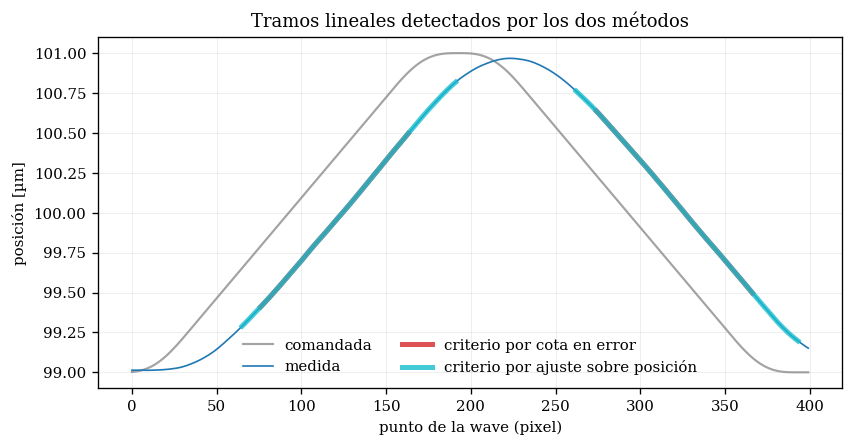

In [7]:
# ---------------------------------------------------------------------------
# VISUALIZACIÓN CONJUNTA DE LOS DOS CRITERIOS
# ---------------------------------------------------------------------------
# Sobre la señal de posición se marca el tramo que cada método considera lineal.
fig, ax = plt.subplots(figsize=(8, 3.8))

ax.plot(r["k"], r["cmd"], color=C_CMD, lw=1.3, alpha=0.8, label="comandada")
ax.plot(r["k"], r["med"], color=C_MED, lw=1.0, label="medida")

color_dict = {"error": "tab:red", "recta": "tab:cyan"}

for clave, m in M.items():
    for j, (pata, idx) in enumerate(m["seg"].items()):
        if len(idx):
            ax.plot(
                r["k"][idx], r["med"][idx],
                color=color_dict[clave], lw=3,
                alpha=0.8,
                label=("criterio por cota en error" if clave == "error" and j == 0
                       else "criterio por ajuste sobre posición" if clave == "recta" and j == 0
                       else None),
            )

ax.set_xlabel("punto de la wave (pixel)")
ax.set_ylabel("posición [µm]")
ax.legend(frameon=False, ncol=2)
ax.set_title("Tramos lineales detectados por los dos métodos")
plt.show()


### Señales de decisión y solapamiento

La primera figura muestra **sobre qué se decidió**: arriba el error menos su meseta, abajo el
residuo a la recta, cada uno con su banda de tolerancia y el tramo aceptado sombreado. En gris
va el residuo contra la recta ajustada sobre *toda* la pata, que se va a cientos de nm justo
donde la platina va más derecha: por eso esa recta sirve para fijar la banda y para arrancar,
pero no como criterio.

La segunda muestra **qué barre cada pasada en el espacio**. La ida y la vuelta no recorren el
mismo tramo: el lazo se atrasa `v·τ` y, como en la vuelta la velocidad cambia de signo, los dos
tramos quedan corridos `2·v·τ`. Ese desfasaje se mide entre los dos puntos que corresponden a la
**misma posición comandada**, no entre las puntas de los tramos — por eso da prácticamente lo
mismo con los dos métodos aunque los tramos tengan largos muy distintos.

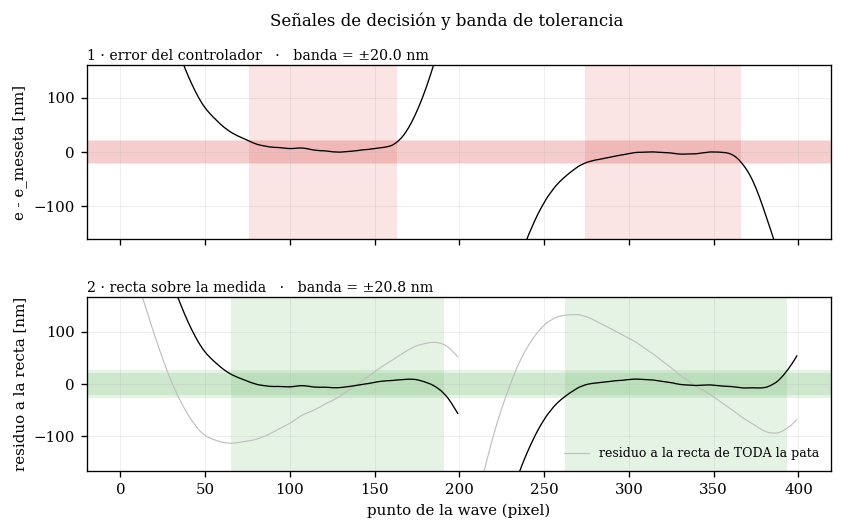

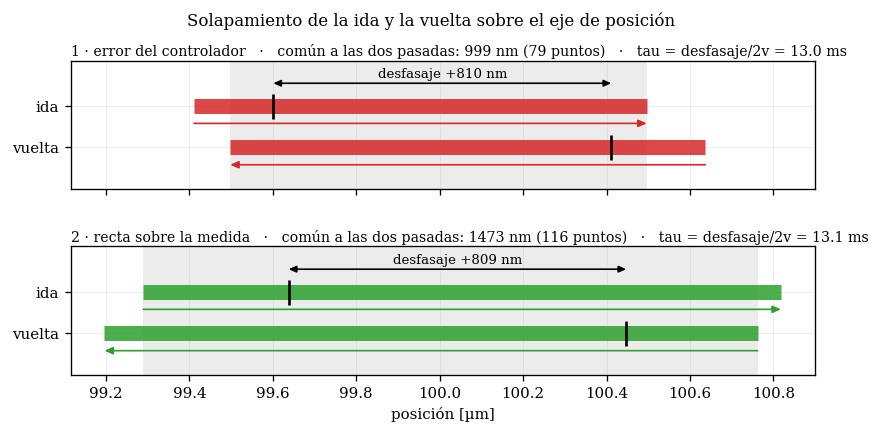

1 · error del controlador     común      999 nm (  79 puntos)   desfasaje     +810 nm   tau =  13.0 ms
2 · recta sobre la medida     común     1473 nm ( 116 puntos)   desfasaje     +809 nm   tau =  13.1 ms


In [8]:
# ---------------------------------------------------------------------------
# LAS SEÑALES CON LAS QUE SE DECIDIÓ, Y EL SOLAPAMIENTO DE LAS DOS PASADAS
# ---------------------------------------------------------------------------
fig_senales(r, M)
plt.show()

fig_solapamiento(r, M)
plt.show()

for clave, m in M.items():
    s = solapamiento(r, m["seg"])
    print(f"{m['nombre']:28s}  común {s['solapamiento_nm']:8.0f} nm "
          f"({s['puntos_comunes']:4.0f} puntos)   desfasaje {s['desfasaje_nm']:+8.0f} nm"
          f"   tau = {s['tau_ms']:5.1f} ms")

## 4. Efecto de WTR: escalonamiento de la señal

Se fijan amplitud, `n_total` y `SUD`, y se cambia únicamente `WTR`.

Con estos parámetros fijos, el paso espacial de la wave es el mismo y cambia el tiempo de permanencia por punto:

\[
t_\mathrm{dwell}=WTR\,T_\mathrm{servo}.
\]

La figura hace un zoom sobre varios peldaños de la región lineal para ver si la posición medida reproduce los escalones comandados o los recorre de forma continua.


In [9]:
# ---------------------------------------------------------------------------
# FAMILIA DE CORRIDAS QUE SOLO DIFIEREN EN WTR
# ---------------------------------------------------------------------------
# Se fijan amplitud, n_total y SUD: el paso espacial dx queda igual y lo unico
# que cambia es cuanto dura cada punto. Esta seleccion la usan las dos figuras
# que siguen, asi que va antes de las dos.
FAMILIA_WTR = dict(amplitud_um=1.0, n_total=400, sud=80)

sel = (
    RAMPAS
    .query(" and ".join(f"{k} == {v}" for k, v in FAMILIA_WTR.items()))
    .drop_duplicates("wtr")
    .sort_values("wtr")
)

corridas_wtr = [cargar(s) for s in sel.stem]

if not corridas_wtr:
    raise ValueError("No se encontraron corridas para FAMILIA_WTR.")

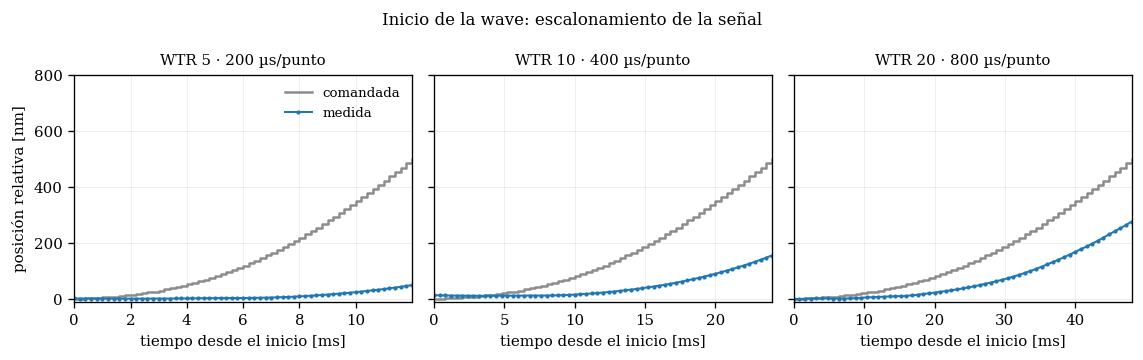

In [10]:
# ---------------------------------------------------------------------------
# COMPARACIÓN DE WTR: INICIO DE LA WAVE
# ---------------------------------------------------------------------------
# Objetivo:
# Mostrar los primeros N_PEldanos de la wave, sin seleccionar previamente
# el tramo lineal. Esto permite observar directamente cómo aparece el
# escalonamiento de la señal medida y cómo depende de WTR.
#
# k = 0 corresponde al primer punto de la wave detectado por cargar(),
# después de eliminar el período inicial de reposo.
# ---------------------------------------------------------------------------

N_PELDANOS = 80

# Offset adicional aplicado solamente a la señal medida [nm].
# Se deja en cero para NO corregir artificialmente la separación entre
# comandada y medida.
OFFSET_EXTRA_NM = 0.0

fig, axes = plt.subplots(
    1,
    len(corridas_wtr),
    figsize=(3.2 * len(corridas_wtr), 3.0),
    sharey=True,
    squeeze=False,
)

axes = axes[0]

for ax, c in zip(axes, corridas_wtr):

    # -----------------------------------------------------------------------
    # Seleccionamos directamente los primeros puntos de la wave.
    # NO usamos metodos() ni buscamos el tramo lineal:
    # queremos observar justamente la respuesta desde el comienzo.
    # -----------------------------------------------------------------------
    k0 = 0
    k1 = min(k0 + N_PELDANOS, c["n_pt"])
    idx = np.arange(k0, k1)

    # Tiempo relativo al comienzo de la wave [ms].
    t = c["t_pt"][idx] - c["t_pt"][idx[0]]

    # -----------------------------------------------------------------------
    # Tomamos como referencia la primera posición comandada.
    #
    # Esto NO corrige el offset entre comandada y medida:
    # simplemente desplazamos ambas curvas para que la comandada comience
    # en 0 nm y podamos comparar visualmente la evolución.
    # -----------------------------------------------------------------------
    referencia = c["cmd"][idx[0]]

    cmd = (c["cmd"][idx] - referencia) * 1e3
    med = (c["med"][idx] - referencia) * 1e3 + OFFSET_EXTRA_NM

    # Wave comandada: se dibuja como escalones porque cada punto de la wave
    # permanece WTR ciclos de servo antes de pasar al siguiente.
    ax.step(
        t,
        cmd,
        where="post",
        color=C_CMD,
        lw=1.5,
        label="comandada",
    )

    # Posición medida por la platina.
    ax.plot(
        t,
        med,
        color=C_MED,
        lw=1.2,
        marker=".",
        ms=3,
        label="medida",
    )

    ax.set_title(
        f"WTR {c['wtr']} · {c['dwell_ms'] * 1e3:.0f} µs/punto",
        fontsize=9,
    )
    ax.set_xlim(left=0, right=t[-20] )
    ax.set_xlabel("tiempo desde el inicio [ms]")

axes[0].set_ylabel("posición relativa [nm]")
axes[0].set_ylim(-10,800)
axes[0].legend(frameon=False, fontsize=8)

fig.suptitle(
    "Inicio de la wave: escalonamiento de la señal",
    fontsize=10,
)


plt.tight_layout()
plt.show()

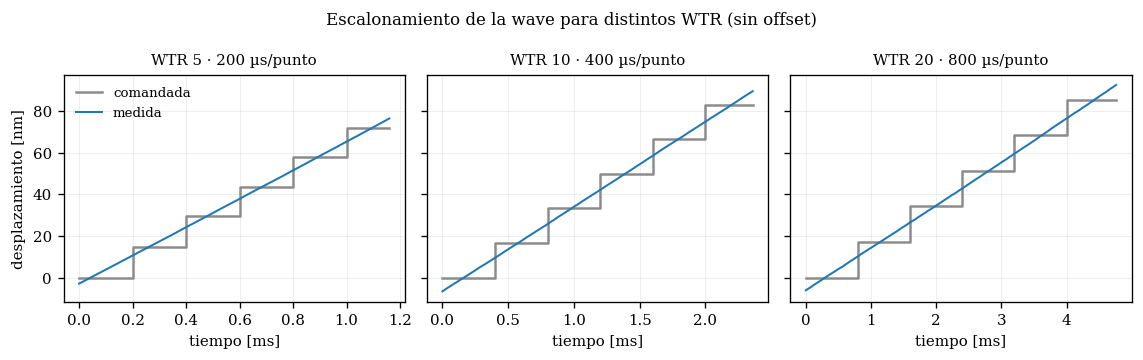

In [11]:
# ---------------------------------------------------------------------------
# COMPARACIÓN DE WTR: ZOOM EN EL TRAMO LINEAL
# ---------------------------------------------------------------------------
N_PELDANOS = 6

# corridas_wtr y N_PELDANOS vienen de las dos celdas anteriores.
fig, axes = plt.subplots(
    1, len(corridas_wtr),
    figsize=(3.2 * len(corridas_wtr), 3.0),
    sharey=True,
    squeeze=False,
)
axes = axes[0]

for ax, c in zip(axes, corridas_wtr):
    # Elegimos una zona central de la pata de ida, lejos de las puntas.
    tramo = metodos(c, TOL)["error"]["seg"]["ida"]
    if len(tramo) < N_PELDANOS + 2:
        continue

    k0 = int(np.median(tramo)) - N_PELDANOS // 2

    # Cada punto de la wave contiene 'muestras_por_punto' muestras del recorder.
    i = np.arange(
        c["arranque"] + k0 * c["muestras_por_punto"],
        c["arranque"] + (k0 + N_PELDANOS) * c["muestras_por_punto"],
    )

    t = c["t_ms"][i] - c["t_ms"][i[0]]
    referencia = c["x_cmd"][i[0]]
    cmd = (c["x_cmd"][i] - referencia) * 1e3
    med = (c["x_med"][i] - referencia) * 1e3

    # Se elimina únicamente el offset medio entre medida y comandada para
    # comparar la FORMA del escalonamiento, no para calcular la velocidad.
    med += np.median(cmd - med)

    ax.step(t, cmd, where="post", color=C_CMD, lw=1.5, label="comandada")
    ax.plot(t, med, color=C_MED, lw=1.2, label="medida")

    ax.set_title(
        f"WTR {c['wtr']} · {c['dwell_ms']*1e3:.0f} µs/punto",
        fontsize=9,
    )
    ax.set_xlabel("tiempo [ms]")

axes[0].set_ylabel("desplazamiento [nm]")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Escalonamiento de la wave para distintos WTR (sin offset)", fontsize=10)
plt.tight_layout()
plt.show()


## 2.a opción de medición representativa

WTR=20 · SUD=0 · amplitud=3.0 µm · puntos=400 · dx medido=30.2 nm


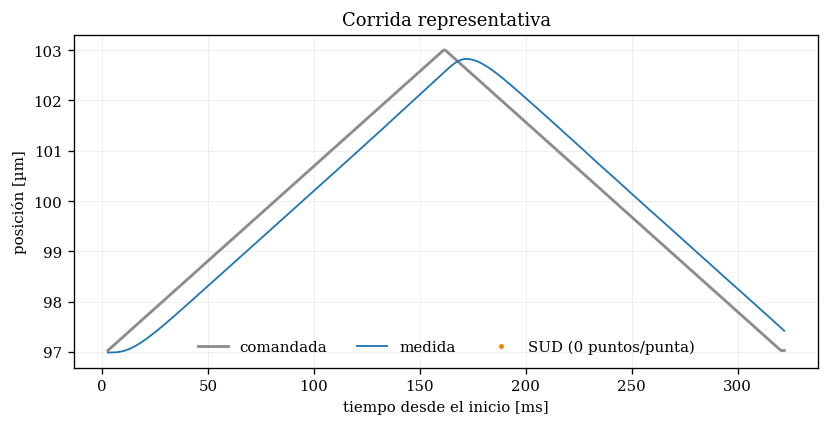

In [23]:

#CORRIDA = "E517_rampa_tau_A30um_20260909_174146_r0"

#CORRIDA = "E517_rampa_tau_A30um_20260909_174151_r1"

CORRIDA ="E517_rampa_tau_A3um_20260909_161237_r0"


r = cargar(CORRIDA)

print(
    f"WTR={r['wtr']} · SUD={r['sud']} · "
    f"amplitud={r['amplitud_um']} µm · puntos={r['n_pt']} · "
    f"dx medido={r['dx_nm']:.1f} nm"
)

fig, ax = plt.subplots(figsize=(8, 3.6))

ax.plot(r["t_pt"], r["cmd"], color=C_CMD, lw=1.7, label="comandada")
ax.plot(r["t_pt"], r["med"], color=C_MED, lw=1.1, label="medida")

# Se resaltan únicamente los puntos SUD de la señal comandada.
# Son los puntos consumidos en las zonas de aceleración/frenado.
ax.plot(
    r["t_pt"][r["es_sud"]],
    r["cmd"][r["es_sud"]],
    ".",
    color=C_SUD,
    ms=4,
    label=f"SUD ({r['sud']} puntos/punta)",
)

ax.set_xlabel("tiempo desde el inicio [ms]")#("punto de la wave (pixel)")
ax.set_ylabel("posición [µm]")
ax.legend(frameon=False, ncol=3)
ax.set_title("Corrida representativa")
plt.show()


In [24]:
# ---------------------------------------------------------------------------
# LOS DOS MÉTODOS
# ---------------------------------------------------------------------------
TOL = 0.05  # 5 % de la meseta del error / del rango del residuo.

M = metodos(r, TOL)

# Tabla compacta: una fila por método y pata.
resultados = []
for clave, m in M.items():
    tabla_m = medir_tramo(r, m["seg"])

    for _, fila in tabla_m.iterrows():
        resultados.append({
            "método": "Error" if clave == "error" else "Posición",
            "pata": fila["pata"],
            "puntos lineales": int(fila["puntos"]),
            "% de la pata": 100 * fila["frac_pata"],
            "v [µm/s]": abs(fila["v_ajuste_um_s"]),
            "σv [µm/s]": fila["err_v_um_s"],
        })

RESULTADOS = pd.DataFrame(resultados)

display(
    RESULTADOS.round({
        "% de la pata": 1,
        "v [µm/s]": 2,
        "σv [µm/s]": 2,
    })
)

,método,pata,puntos lineales,% de la pata,v [µm/s],σv [µm/s]
0,Error,ida,140,70.0,37.79,0.01
1,Error,vuelta,106,53.0,37.92,0.02
2,Posición,ida,169,84.5,37.97,0.01
3,Posición,vuelta,173,86.5,37.86,0.01


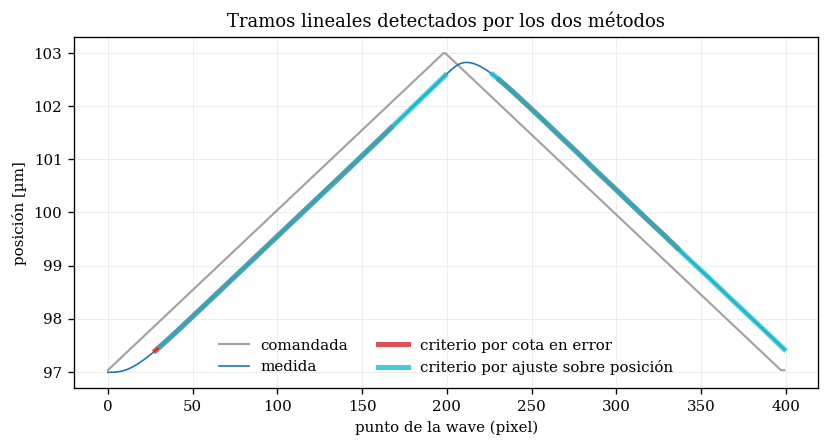

In [25]:
# ---------------------------------------------------------------------------
# VISUALIZACIÓN CONJUNTA DE LOS DOS CRITERIOS
# ---------------------------------------------------------------------------
# Sobre la señal de posición se marca el tramo que cada método considera lineal.
fig, ax = plt.subplots(figsize=(8, 3.8))

ax.plot(r["k"], r["cmd"], color=C_CMD, lw=1.3, alpha=0.8, label="comandada")
ax.plot(r["k"], r["med"], color=C_MED, lw=1.0, label="medida")

color_dict = {"error": "tab:red", "recta": "tab:cyan"}

for clave, m in M.items():
    for j, (pata, idx) in enumerate(m["seg"].items()):
        if len(idx):
            ax.plot(
                r["k"][idx], r["med"][idx],
                color=color_dict[clave], lw=3,
                alpha=0.8,
                label=("criterio por cota en error" if clave == "error" and j == 0
                       else "criterio por ajuste sobre posición" if clave == "recta" and j == 0
                       else None),
            )

ax.set_xlabel("punto de la wave (pixel)")
ax.set_ylabel("posición [µm]")
ax.legend(frameon=False, ncol=2)
ax.set_title("Tramos lineales detectados por los dos métodos")
plt.show()


### Señales de decisión y solapamiento

La primera figura muestra **sobre qué se decidió**: arriba el error menos su meseta, abajo el
residuo a la recta, cada uno con su banda de tolerancia y el tramo aceptado sombreado. En gris
va el residuo contra la recta ajustada sobre *toda* la pata, que se va a cientos de nm justo
donde la platina va más derecha: por eso esa recta sirve para fijar la banda y para arrancar,
pero no como criterio.

La segunda muestra **qué barre cada pasada en el espacio**. La ida y la vuelta no recorren el
mismo tramo: el lazo se atrasa `v·τ` y, como en la vuelta la velocidad cambia de signo, los dos
tramos quedan corridos `2·v·τ`. Ese desfasaje se mide entre los dos puntos que corresponden a la
**misma posición comandada**, no entre las puntas de los tramos — por eso da prácticamente lo
mismo con los dos métodos aunque los tramos tengan largos muy distintos.

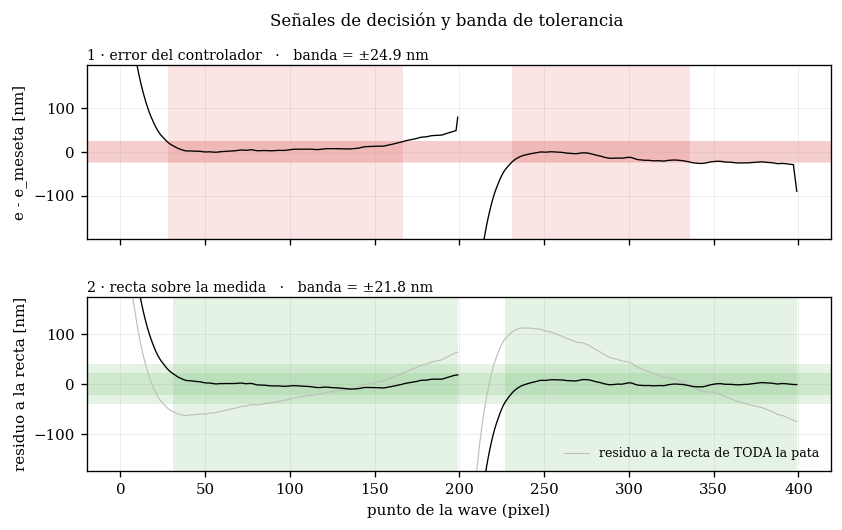

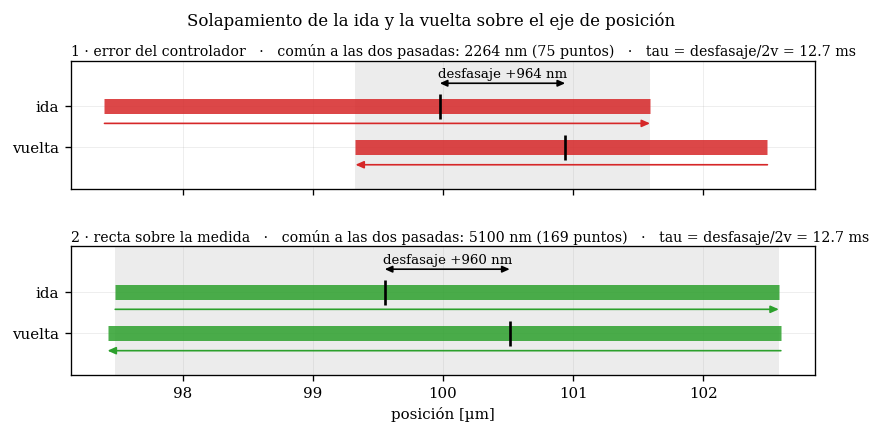

1 · error del controlador     común     2264 nm (  75 puntos)   desfasaje     +964 nm   tau =  12.7 ms
2 · recta sobre la medida     común     5100 nm ( 169 puntos)   desfasaje     +960 nm   tau =  12.7 ms


In [26]:
# ---------------------------------------------------------------------------
# LAS SEÑALES CON LAS QUE SE DECIDIÓ, Y EL SOLAPAMIENTO DE LAS DOS PASADAS
# ---------------------------------------------------------------------------
fig_senales(r, M)
plt.show()

fig_solapamiento(r, M)
plt.show()

for clave, m in M.items():
    s = solapamiento(r, m["seg"])
    print(f"{m['nombre']:28s}  común {s['solapamiento_nm']:8.0f} nm "
          f"({s['puntos_comunes']:4.0f} puntos)   desfasaje {s['desfasaje_nm']:+8.0f} nm"
          f"   tau = {s['tau_ms']:5.1f} ms")